In [412]:
from cuda_cqed.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

Hamiltonian:
$$
H = g_2 (aa + a^{\dagger} a^{\dagger})
$$

the EoMs are
$$
\dot{\langle a \rangle} = - 2i g_2 \langle a \rangle^{\dagger}
$$

$$
\dot{\langle aa \rangle} = - 2 i g_2 - 4 i g_2 \langle a^{\dagger} a \rangle
$$

$$
\dot{\langle a^{\dagger} a \rangle} = + 2 i g_2 \langle aa \rangle  - 2 i g_2 \langle a^{\dagger} a^{\dagger} \rangle
$$

And for below, $g_2 = g_3 s_1$

In [714]:
g3 = 3e-3
s1 = 1
g2 = g3*s1

disp = 1

In [715]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('wb', 0e9*2*pi, is_excitation=True)
# sim.add_param('sqrtkb', np.sqrt(1e7 * 2 * np.pi)) # in MHz
sim.add_param('g3', g3)
sim.add_paramsweep('amplG', 0, s1, 101)  # 18 - gain
sim.add_param('IC', disp)

sim.add_EOM('s1', '0', IC_str='amplG')

# sim.add_EOM('b', '-1j*wb*b - (sqrtkb**2/2)*b + 1j*g3*conjugate(b)*s1 - 1j*b*K*abs(b)**2',IC_str='IC')
sim.add_EOM('b', '- 2j*g3*conjugate(b)*s1',IC_str='IC')
sim.add_EOM('bb', '-2j*g3*s1 - 4j*g3*s1*nb', IC_str='IC**2')
sim.add_EOM('nb', '2j*g3*bb*s1 - 2j*g3*conjugate(bb)*s1',IC_str='IC**2')

sim.set_solve_type('all')

sim.specify_time(t_f=200, pts=5001)

sim.validate()

Recent change to specify_time(), check implementation
Simulation validation success!


In [716]:
x, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|████████████████████████████████████████████████████████████████████████████| 5001/5001 [00:03<00:00, 1580.77it/s]

 
...finished GPU solve!


In [717]:
xd = x.copy()
td = t.copy()

In [718]:
b = x[2,:]+1j*x[3,:]
bb = x[4,:]+1j*x[5,:]
nb = x[6,:]+1j*x[7,:]

In [719]:
def plot_Qfunc(a, aa, na, ax=None, plot_arg=None):

    if ax == None:
        ax = plt.gca()
    
    ad = np.conjugate(a)
    adad = np.conjugate(aa)
    sxx = 1/2 + 1/2*( (aa - a*a) + 2*(na - ad*a) + (adad - ad*ad))
    syy = 1/2 - 1/2*( (aa - a*a) - 2*(na - ad*a) + (adad - ad*ad))
    sxy = np.imag(1/2*((aa - a*a) - (adad - ad*ad)))
    covar =  np.real(np.array([[sxx, sxy], [sxy, syy]]))

    print(covar)
    print(' ')

    phi = np.linspace(0, 2*np.pi, 101)
    
    print(np.argsort(np.linalg.eig(covar)[0]))

    order = np.argsort(np.linalg.eig(covar)[0])
    major_idx = order[1]
    minor_idx = order[0]
    
    theta = -np.angle(np.linalg.eig(covar)[1][:,1][minor_idx]+1j*np.linalg.eig(covar)[1][:,1][major_idx])
    Smajor = np.sort(np.linalg.eig(covar)[0])[major_idx]
    Sminor = np.sort(np.linalg.eig(covar)[0])[minor_idx]
    
    x1 = np.sqrt(Smajor)*np.cos(phi)*2
    y1 = np.sqrt(Sminor)*np.sin(phi)*2
    
    x2 = x1*np.cos(theta) + y1*np.sin(theta) + np.real(a)
    y2 = -x1*np.sin(theta) + y1*np.cos(theta) + np.imag(a)

    if plot_arg == None:
        ax.plot(x2,y2)
    else:
        ax.plot(x2,y2,plot_arg)
    # ax.xlim([-7,7])
    # ax.ylim([-7,7])
    # plt.gca().set_aspect('equal')
    # plt.grid()
    # plt.show()


[[ 2.77847364 -2.73311466]
 [-2.73311466  2.77847364]]
 
[0 1]


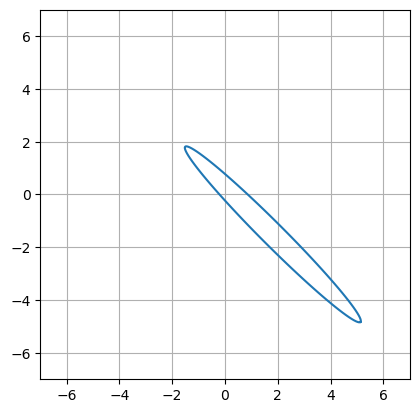

In [720]:
i = -1
j = -1
plot_Qfunc(b[i,j], bb[i,j], nb[i,j])
plt.xlim([-7,7])
plt.ylim([-7,7])
plt.gca().set_aspect('equal')
plt.grid()
plt.show()

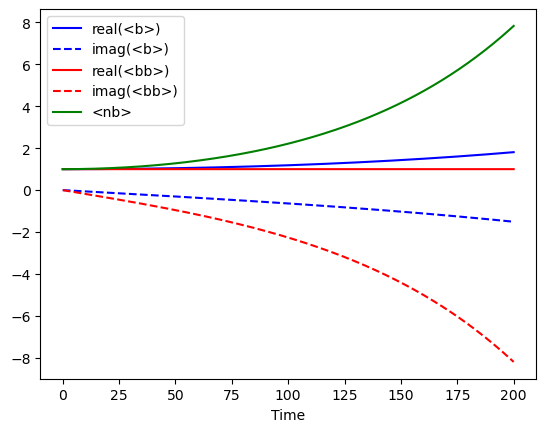

In [721]:
tlist = np.unique(tlist)
plt.plot(tlist, np.real(b[i,:]),'b-',label='real(<b>)')
plt.plot(tlist, np.imag(b[i,:]),'b--',label='imag(<b>)')
plt.plot(tlist, np.real(bb[i,:]),'r-',label='real(<bb>)')
plt.plot(tlist, np.imag(bb[i,:]),'r--',label='imag(<bb>)')
plt.plot(tlist, np.real(nb[i,:]),'g',label='<nb>')
plt.legend()
plt.xlabel('Time')
plt.show()

# QuTiP version

In [722]:
from base64 import b64encode

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib import animation
from qutip import (about, basis, coherent, destroy, displace, expect, mesolve,
                   num, plot_fock_distribution, plot_wigner, squeeze, variance, Options)

%matplotlib inline

In [723]:
N = 100
w = 0 * 2 * np.pi  # oscillator frequency
tlist = np.linspace(0, 200, 5001)  # periods

# operators
a = destroy(N)
n = num(N)
x = (a + a.dag()) / np.sqrt(2)
p = -1j * (a - a.dag()) / np.sqrt(2)

H = w * a.dag() * a + g2*(a.dag()**2 + a**2)

c_ops = []

In [724]:
def plot_expect_with_variance(N, op_list, op_title, states):
    """
    Plot the expectation value of an operator (list of operators)
    with an envelope that describes the operators variance.
    """

    fig, axes = plt.subplots(1, len(op_list), figsize=(14, 3))

    for idx, op in enumerate(op_list):

        e_op = expect(op, states)
        v_op = variance(op, states)

        axes[idx].fill_between(
            tlist, e_op - np.sqrt(v_op), e_op + np.sqrt(v_op), color="green",
            alpha=0.5)
        axes[idx].plot(tlist, e_op, label="expectation")
        axes[idx].set_xlabel("Time")
        axes[idx].set_title(op_title[idx])

    return fig, axes

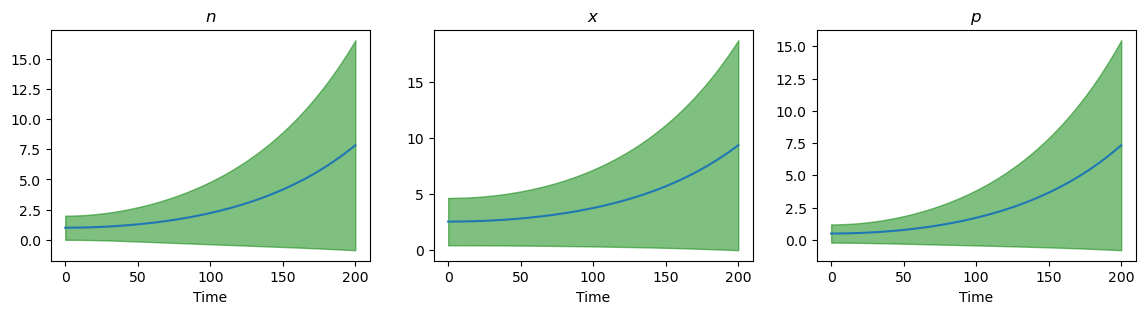

In [725]:
psi0 = coherent(N, disp)

result = mesolve(H, psi0, tlist, c_ops, [], options={'nsteps': 100000})

plot_expect_with_variance(N, [n, x*x, p*p], [r"$n$", r"$x$", r"$p$"],
                          result.states);
plt.show()

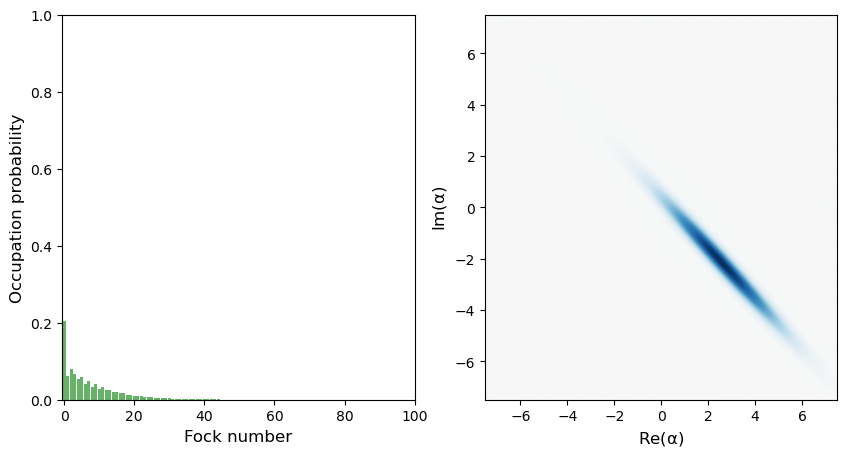

In [726]:
# i = 0

# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# axes[0].cla()
# plot_fock_distribution(result.states[i], fig=fig, ax=axes[0])
# plot_wigner(result.states[i], fig=fig, ax=axes[1])
# plt.show()

i = -1

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].cla()
plot_fock_distribution(result.states[i], fig=fig, ax=axes[0])
plot_wigner(result.states[i], fig=fig, ax=axes[1])
plt.show()

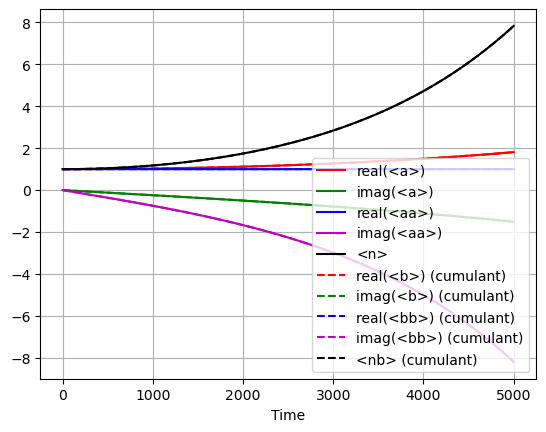

In [727]:
plt.plot(np.real(expect(a, result.states)),'r-',label='real(<a>)')
plt.plot(np.imag(expect(a, result.states)),'g-',label='imag(<a>)')
plt.plot(np.real(expect(a*a, result.states)),'b-',label='real(<aa>)')
plt.plot(np.imag(expect(a*a, result.states)),'m-',label='imag(<aa>)')
plt.plot(expect(a.dag()*a, result.states),'k-',label='<n>')

plt.plot(np.real(b[i,:]),'r--',label='real(<b>) (cumulant)')
plt.plot(np.imag(b[i,:]),'g--',label='imag(<b>) (cumulant)')
plt.plot(np.real(bb[i,:]),'b--',label='real(<bb>) (cumulant)')
plt.plot(np.imag(bb[i,:]),'m--',label='imag(<bb>) (cumulant)')
plt.plot(np.real(nb[i,:]),'k--',label='<nb> (cumulant)')
plt.legend()
plt.grid()
plt.xlabel('Time')
plt.show()

# Overlay comparison

(1.8106555830692894-1.5094613742987861j) (1-8.199343994404561j) (7.835420921499906+0j)
[[ 2.77847364 -2.73311466]
 [-2.73311466  2.77847364]]
 
[0 1]


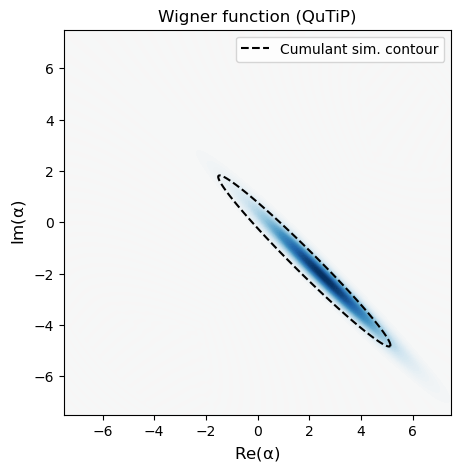

In [728]:
i = -1
j = -1

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.cla()
plot_wigner(result.states[i], fig=fig, ax=ax)

print(b[i,j], bb[i,j], nb[i,j])
plot_Qfunc(b[i,j], bb[i,j], nb[i,j], plot_arg='k--')
plt.legend(['Cumulant sim. contour'])
plt.title('Wigner function (QuTiP)')
plt.show()

[[ 2.77847364 -2.73311466]
 [-2.73311466  2.77847364]]
 
[0 1]


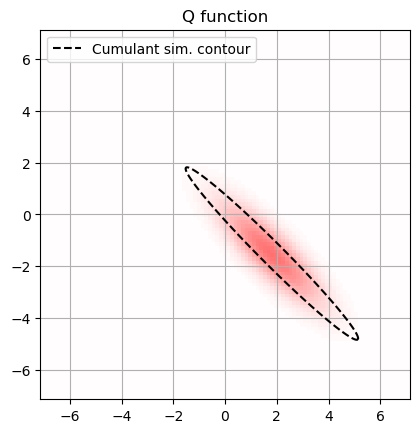

[[ 2.77847364 -2.73311466]
 [-2.73311466  2.77847364]]
 
[0 1]


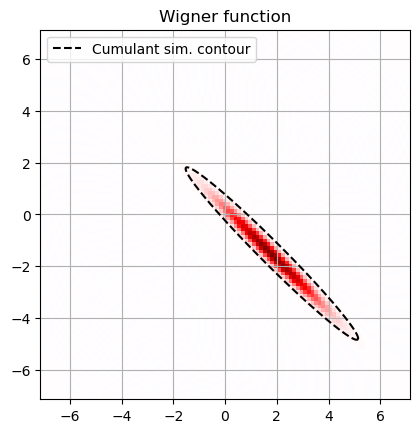

In [732]:
from qutip.wigner import qfunc, wigner

'''
TODO: why do I need the 1/sqrt(2)
'''

xvec = np.linspace(-10,10,101)

plot_Qfunc(b[i,j], bb[i,j], nb[i,j], plot_arg='k--')
plt.legend(['Cumulant sim. contour'],loc='upper left')
plt.pcolor(xvec/np.sqrt(2), xvec/np.sqrt(2), qfunc(result.states[i], xvec, xvec),cmap='seismic',clim=([-1/np.pi,1/np.pi]))
plt.gca().set_aspect('equal')
plt.grid()
plt.title('Q function')

plt.show()

plot_Qfunc(b[i,j], bb[i,j], nb[i,j], plot_arg='k--')
plt.legend(['Cumulant sim. contour'],loc='upper left')
plt.pcolor(xvec/np.sqrt(2), xvec/np.sqrt(2), wigner(result.states[i], xvec, xvec),cmap='seismic',clim=([-1/np.pi,1/np.pi]))
plt.gca().set_aspect('equal')
plt.grid()
plt.title('Wigner function')

plt.show()

# Some confusions

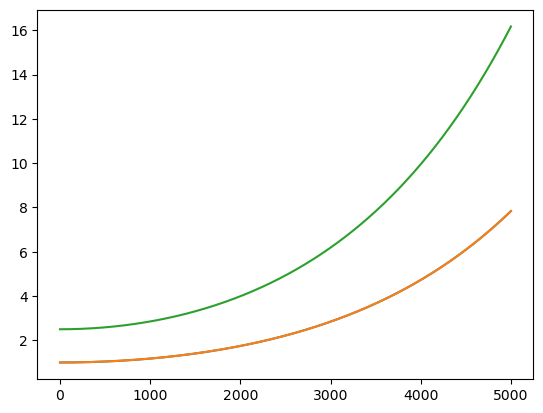

In [730]:
# following Girvin's cqed, they should all be the same, but they are not
plt.plot(expect(a.dag()*a, result.states))
plt.plot(expect(n, result.states))
plt.plot(expect(x*x+p*p-0.5, result.states))
plt.show()